### Higher-order derivatives
Let's first describe the meaning of higher-order derivatives.

The first derivative represents **speed**, the second shows **acceleration**, and the third describes **jerk**. Put differently, the first derivative gives us the **slope**, the second shows how that **slope changes**, and the third captures **how those changes themselves vary** - by indicating quick, sharp, or sudden movements.

![Higher order derivatives](img/higher_order_derivatives.jpg)

One of the most useful things about higher-order derivatives is how they help us in approximating functions.



### Function approximation
**Function approximation** is a fundamental problem in machine learning, where the goal is to approximate an unknown function from a set of input-output data pairs. Function approximation involves approximating an unknown function $f(x)$ using a set of input-output data pairs $(x, y)$. The goal is to build a function $g(x)$ that is as close to the unknown function $f(x)$ as possible, based on the available data.


### Computing Function Value Approximations

Some functions can be really hard to compute, or even impossible. However, there are ways to approximate functions with other functions, which are simpler. The idea is the same as what we already used: we approximated the function with its tangent line to find the derivative at a given point. 

Let's research what **Taylor polynomial** and **Taylor series** are and how they're used in approximating functions. After that let's derive and implement the **Taylor expansions** of several functions.

### Taylor Polynomial
The study of Taylor Polynomial is largely about taking non-polynomial functions and finding polynomials the approximate them near some input.
The motive here is that polynomials tend to be much easier to deal with than other functions. They are easier to compute, easier to take derivatives, easier to integrate.

For example, let's try to approximate $cos(x)$ function. It looks like this.

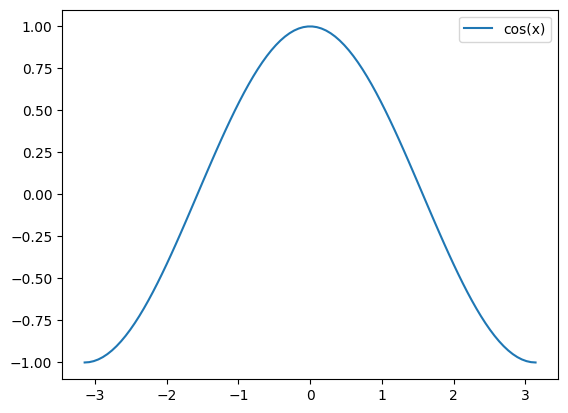

In [272]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-np.pi, np.pi, 100)
y = np.cos(x)

plt.plot(x, y, label='cos(x)')
plt.legend()
plt.show()



The polynomial we are looking for looks like this:
$$ P(x) = c_0 + c_1x + c_2x^2 + ... $$

##### Step 1: Pick a point at which to approximate
Firstly, we need to select a point at which we want the origin function and the target polynomial to behave the same. It is common to pick $0$.
$$cos(0) = 1$$
So, we need our polynomial to also be equal to zero when $x = 0$. This means that:

$$ P(0) = c_0 + c_10 + c_20^2 = 1 $$

Obviously $c_0$ must be equal to $1$.

So far, our polynomial looks like this $P(x) = 1$

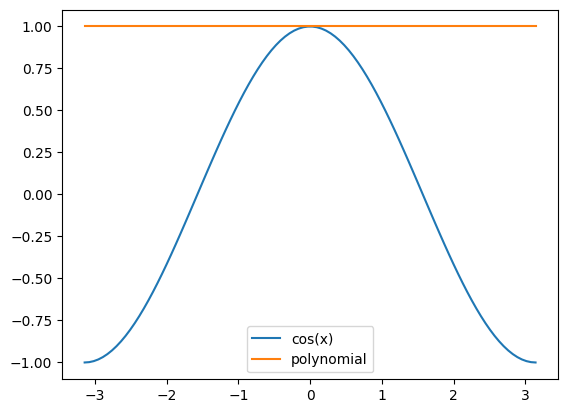

In [273]:
polynomial = np.full(100, 1)

plt.plot(x, y, label='cos(x)')
plt.plot(x, polynomial, label='polynomial')
plt.legend()
plt.show()

Obviously, our polynomial is far from good approximation. That's why we take second step.

##### Step 2: Approximate the first derivative
We want the first derivatives of both $cos(x)$ and $P(x)$ to have equal values at point $0$. This way the **tangent line** for both functions at $0$ will be the same.

The first derivative of $cos(x)$ is $-sin(x)$. 

And the first derivative of $P(x) = 1 + c_1x + c_2x^2$ is $P'(x) = c_1 + 2c_2x$

In other words we want:

$$ P'(x) = c_1 + 2c_2x = -sin(x) $$
or
$$ P'(0) = c_1 + 2c_20 = -sin(0) $$

Knowing that $-sin(0) = 0$ we can conclude that $c_1$ must also be $0$.

So far, our approximation polynomial looks like this:

$$ P(x) = 1 + 0x + c_2x^2 $$

##### Step 3: Approximate the second derivative
We want the second derivatives to also be equal at point $0$. This way the **tangent line** for both functions at $0$ will be the same.

$$cos''(x) = -cos(x)$$
$$cos''(0) = -1$$
$$ P''(x) = 2c_2 = -1 $$

So the $c_2$ coefficient must  be $-\frac{1}{2}$.



And our polynomial looks like this now:

$$ P(x) = 1 + 0x - \frac{1}{2}x^2 $$

Let's see how close it is to the origin function.

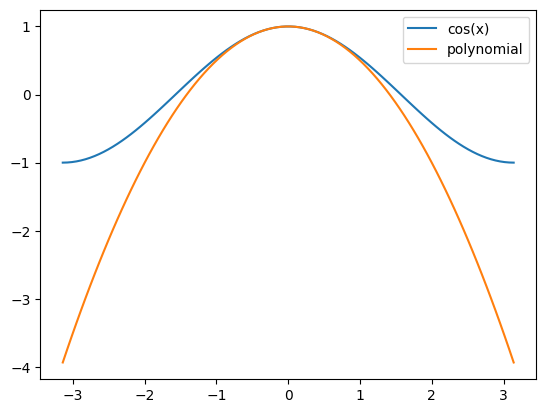

In [274]:
polynomial = lambda x: 1 + 0*x - 0.5*x**2

plt.plot(x, y, label='cos(x)')
plt.plot(x, polynomial(x), label='polynomial')
plt.legend()
plt.show()

We are getting there. Let's continue this process of approximate with 3rd and 4th derivatives. In result the polynomial now looks like this:
$$ P(x) = 1 + 0x - \frac{1}{2}x^2 + 0x^3 + \frac{1}{24}x^4$$

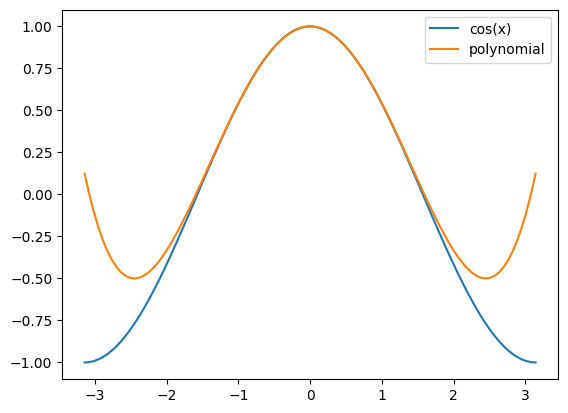

In [275]:
polynomial = lambda x: 1 + 0*x - 0.5*x**2 + 0*x**3 + (1/24)*x**4

plt.plot(x, y, label='cos(x)')
plt.plot(x, polynomial(x), label='polynomial')
plt.legend()
plt.show()

Yep, we are getting closer and closer. 

If we spin two more rounds of derivatives the polynomial would look like this:
$$ P(x) = 1 + 0x - \frac{1}{2}x^2 + 0x^3 + \frac{1}{24}x^4 + 0x^5 - \frac{1}{720}x^6$$

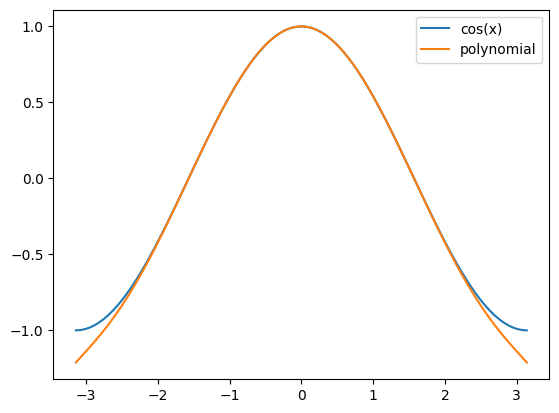

In [276]:
polynomial = lambda x: 1 + 0*x - 0.5*x**2 + 0*x**3 + (1/24)*x**4 + 0*x**5 - (1/720)*x**6

plt.plot(x, y, label='cos(x)')
plt.plot(x, polynomial(x), label='polynomial')
plt.legend()
plt.show()

What we observe is that we can generalize the recipy for that polynomial:

$$ P(x) = 1 + 0\frac{1}{1!}x - 1 \frac{1}{2!}x^2 + 0\frac{1}{3!}x^3 + 1 \frac{1}{4!}x^4 + 0\frac{1}{5!}x^5 - 1 \frac{1}{6!}x^6  $$

The coeficients are related once to the **degree of the terms** ($\frac{1}{1!}$, $\frac{1}{2!}$, $\frac{1}{3!}$, etc.) and to the corresponding **derivative values** of the origin function:

$$cos(0) = 1$$
$$cos'(0) = -sin(0) = 0$$
$$cos''(0) = -cos(0) = -1$$
$$cos'''(0) = sin(0) = 0$$
$$cos''''(0) = cos(0) = 1$$
$$cos'''''(0) = -sin(0) = 0$$
$$cos''''''(0) = -cos(0) = -1$$

So, this polynomial we build by the above iterative approach is called **Taylor polynomial**.

### Taylor Series
In math an infinite sum is called **series**, so even though we can get a decent approximation with a **finite** polynomial (Taylor polynomial), adding all infinitely many terms gives what is called **Taylor series**.

$$ cos(x) \approx 1 - \frac{x^2}{2!} + \frac{x^4}{4!} - \frac{x^6}{6!} + \frac{x^8}{8!} - ... $$

So, in general the formula for Taylor series looks like this:

$$ P(x) = c_0 + c_1(x - a) + c_2(x - a)^2 + ... $$

Where $c_0, c_1$, ... are coefficients on each polynomial term, and $a$ is a constant that represents where along the $x$-axis we want to start our approximation (if we don’t care where we start, just let $a = 0$, which is technically known as a **Maclaurin series** rather than a Taylor one).

This series — known as a “power series” — can be written in closed form as the following:

$$ P(x) = \sum_{i=0}^{\infty} c_i(x - a)^i $$

Now we can replace $c_i$ coefficients with the $factorial$ magic we examined in the $cos(x)$ example and the formula would look like this:


$$ P(x) = \frac{f(a)}{0!} + \frac{f'(a)}{1!}(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + ... $$

or written in short:

$$ P(x) = \sum_{i=0}^{\infty} \frac{f^{(i)}(a)}{i!}(x-a)^i $$


### Converge vs Diverge
Please note that a Taylor series has a certain **interval of convergence**, which defines the interval around the center point (where the approximation is being looked for) within which the series converges to the function. Outside this interval, the series may **diverge**.

### Implementation

Now let's implement that formula in Python.

Firstly, let's import required libraries.  

In [277]:
from typing import Callable
import numpy as np
import matplotlib.pyplot as plt

Now let's define some utility functions.

In [278]:
def factorial(n: int) -> int:
    """Recursively calculates the factorial of a number."""
    if n == 0:
        return 1
    return n * factorial(n-1)

def derivative_at_point(f: Callable, x: float, h: float = 1e-3) -> float:
    """Calculates a numerical approximation to the derivative of the specified function at the given point x."""
    return (f(x+h) - f(x-h)) / (2*h)

def nth_derivative_at_point(f: Callable, x: float, n: int) -> float:
    """Recursively calculates the nth derivative of a function."""
    if n == 0:
        return f(x)
    return nth_derivative_at_point(lambda y: derivative_at_point(f, y), x, n-1)

And now let's implement the Taylor Series formula.

In [279]:
def taylor_series(f: Callable, a: float, num_terms: int) -> Callable:
    """
    Compute the Taylor series expansion of a function 'f' around a point 'a'.

    Args:
        f: The function to approximate
        a: The point around which to approximate
        num_terms: The number of terms to include in the series

    Returns:
        A function that computes the Taylor series approximation
    """

    def taylor_series_approximation(x: float) -> float:
        """Compute the Taylor series approximation of 'f' around a point 'a'."""
        result = 0  
        for i in range(num_terms):
            ith_derivative = nth_derivative_at_point(f, a, i)
            result += (ith_derivative / factorial(i)) * ((x - a) ** i)
        return result

    return taylor_series_approximation

Now let's test our implementation with $cos(x)$.

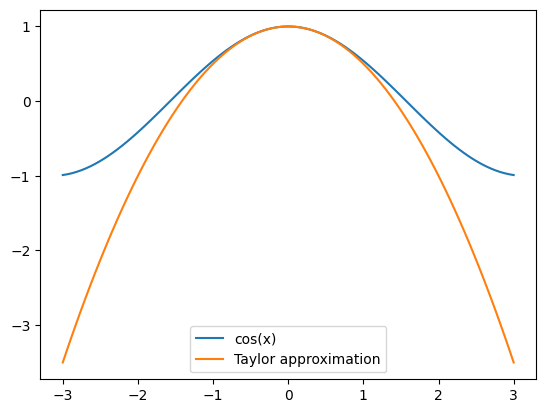

In [280]:
origin_function = np.cos
taylor_approximation = taylor_series(origin_function, 0, 4)

x_domain = np.linspace(-3, 3, 100)

plt.plot(x_domain, origin_function(x_domain), label='cos(x)')
plt.plot(x_domain, taylor_approximation(x_domain), label='Taylor approximation')
plt.legend()
plt.show()

Now let's check the curious exponential function.

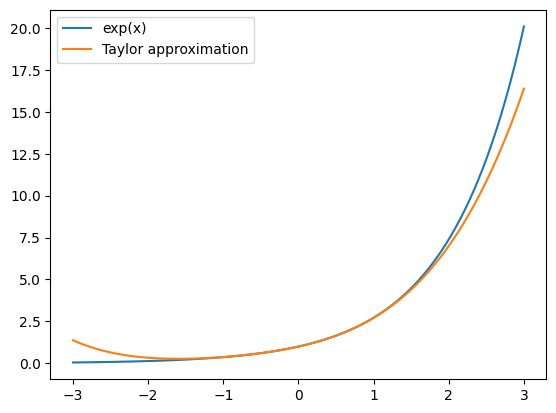

In [281]:
origin_function = np.exp
taylor_approximation = taylor_series(origin_function, 0, 5)

x_domain = np.linspace(-3, 3, 100)

plt.plot(x_domain, origin_function(x_domain), label='exp(x)')
plt.plot(x_domain, taylor_approximation(x_domain), label='Taylor approximation')
plt.legend()
plt.show()

### Conclusion
Taylor series simply work. To some accuracy. And to some interval of convergence (short distance around the approximation point). But it works.

When the origin function is smooth (having derivatives to the $n$-th order), the fitting of the polynomial is good because a polynomial is smooth as well.

### References
* [Taylor series | Chapter 11, Essence of calculus](https://www.youtube.com/watch?v=3d6DsjIBzJ4)
* [An Easy Way to Remember the Taylor Series Expansion](https://medium.com/@andrew.chamberlain/an-easy-way-to-remember-the-taylor-series-expansion-a7c3f9101063)